In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/race_data.csv")

df.head() per caricare le prime 5 righe del dataset. Sanity check

In [11]:
df.head()

,Driver,GP,StartType,StartPos,FinishPos,Delta,Stops,FirstPitLap,Status
0,PIA,Bahrain,Grid,1,1,0.0,2,14,Finished
1,LEC,Bahrain,Grid,2,5,-3.0,2,17,Finished
2,RUS,Bahrain,Grid,3,2,1.0,2,13,Finished
3,GAS,Bahrain,Grid,4,7,-3.0,2,10,Finished
4,ANT,Bahrain,Grid,5,11,-6.0,3,12,Finished


Statistiche descrittive delle colonne numeriche
count = quantitativo osservazioni
mean = media
std = deviazione standard
min = minimo
25% = primo quartile
50% = mediana
75% = terzo quartile
max = massimo

In [8]:
df.describe()

,Delta
count,69.000000
mean,1.202899
std,4.648149
min,-10.000000
25%,-1.000000
50%,1.000000
75%,3.000000
max,20.000000


Quantitativo delle varie stop strategies

In [10]:
df["Stops"].value_counts()

Stops
2    49
1    22
3     5
0     3
-     1
Name: count, dtype: int64

Calcolo la **Media** e la **Mediana** del Delta per i vari GP.

In [11]:
df.groupby("GP")["Delta"].mean()

GP
Bahrain        1.333333
Monaco         0.888889
Monza          1.111111
Silverstone    1.533333
Name: Delta, dtype: float64

In [12]:
df.groupby("GP")["Delta"].median()

GP
Bahrain        1.0
Monaco         1.0
Monza          0.0
Silverstone    1.0
Name: Delta, dtype: float64

Non noto differenze troppo evidenti oltre a Monza: 1.111111 -> 0.0

---

Statistiche per ogni circuito

In [13]:
df.groupby("GP")["Delta"].describe()

,count,mean,std,min,25%,50%,75%,max
GP,,,,,,,,
Bahrain,18.0,1.333333,5.498663,-6.0,-1.75,1.0,2.75,20.0
Monaco,18.0,0.888889,3.027111,-5.0,0.00,1.0,2.00,8.0
Monza,18.0,1.111111,3.512815,-4.0,-0.75,0.0,3.50,10.0
Silverstone,15.0,1.533333,6.468237,-10.0,-2.50,1.0,4.50,16.0


---

Analisi del quantitativo delle strategie per ogni GP

In [14]:
df.groupby("GP")["Stops"].value_counts()

GP           Stops
Bahrain      2        18
             3         2
Monaco       2        17
             1         2
             3         1
Monza        1        19
             -         1
Silverstone  2        14
             0         3
             3         2
             1         1
Name: count, dtype: int64

---

Domanda iniziale: I piloti con strategie 1-stop hanno un delta medio diverso da quelli con strategie 2-stop?

Esploro se il numero di stop mostra differenze nel Position Delta.

In [15]:
df.groupby("Stops")["Delta"].mean()

Stops
-         NaN
0         NaN
1    1.111111
2    1.187500
3    2.000000
Name: Delta, dtype: float64

Possiamo assumere, per ora, che le strategie 1 stop e 2 stop (1.11 vs 1.19) sono simili quindi, *il numero di stop di per se non dice molto*

In [17]:
df["Stops"].value_counts()

Stops
2    49
1    22
3     5
0     3
-     1
Name: count, dtype: int64

In [ ]:
df.groupby("Stops")["Delta"].median()

Stops
-    NaN
0    NaN
1    0.0
2    1.0
3    2.0
Name: Delta, dtype: float64

Dalla mediana possiamo vedere che le strategie a 2-stop hanno un leggero miglioramento comparandole a quelle ad 1-stop (49 casi vs 22). Non possiaamo assumere lo stesso per le strategie a 3-stop vedendo che abbiamo solo 5 casi nelle quali accadono.

---

In [5]:
df.groupby("Stops")["Delta"].describe()

,count,mean,std,min,25%,50%,75%,max
Stops,,,,,,,,
-,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18.0,1.111111,3.512815,-4.0,-0.75,0.0,3.5,10.0
2,48.0,1.187500,4.901829,-10.0,-1.25,1.0,3.0,20.0
3,3.0,2.000000,8.000000,-6.0,-2.00,2.0,6.0,10.0


In [6]:
df.groupby(["GP","Stops"])["Delta"].median()

GP           Stops
Bahrain      2         1.0
             3        -6.0
Monaco       1         NaN
             2         1.0
             3         2.0
Monza        -         NaN
             1         0.0
Silverstone  0         NaN
             1         NaN
             2         1.0
             3        10.0
Name: Delta, dtype: float64

---


## 📊 Visual Analysis
Exploring relationships through plots.

In [1]:
import matplotlib.pyplot as plt

## Distribution of Pit Stop Strategies by Grand Prix

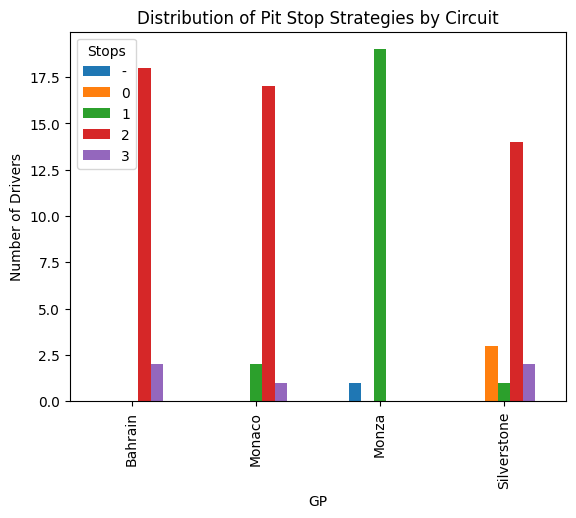

In [8]:
df.groupby("GP")["Stops"].value_counts().unstack().plot(kind="bar")
plt.title("Distribution of Pit Stop Strategies by Circuit")
plt.ylabel("Number of Drivers")
plt.savefig("../plots/pitstop_distribution_by_gp.png", bbox_inches="tight")
plt.show()

---

## Relationship Between First Pit Stop Timing and Race Outcome

In [10]:
df["FirstPitLap"] = pd.to_numeric(df["FirstPitLap"], errors="coerce")

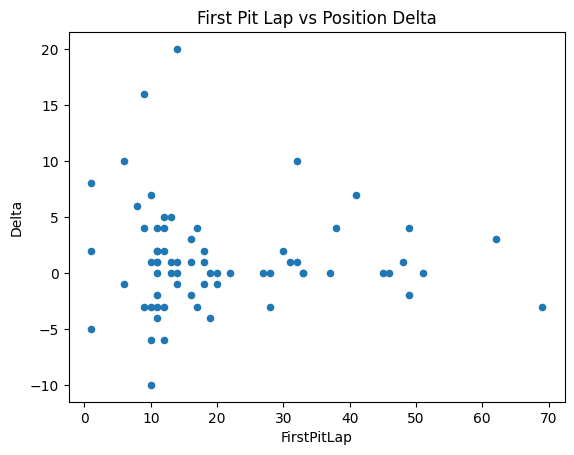

In [11]:
df.plot.scatter(x="FirstPitLap", y="Delta")
plt.title("First Pit Lap vs Position Delta")
plt.savefig("../plots/first_pit_vs_delta.png", bbox_inches="tight")
plt.show()